--- Loading Cleaned Dataset ---


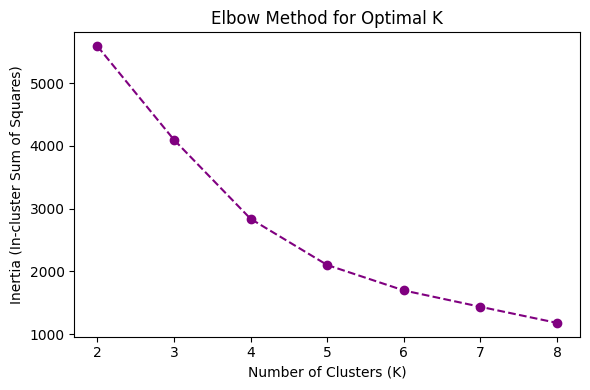

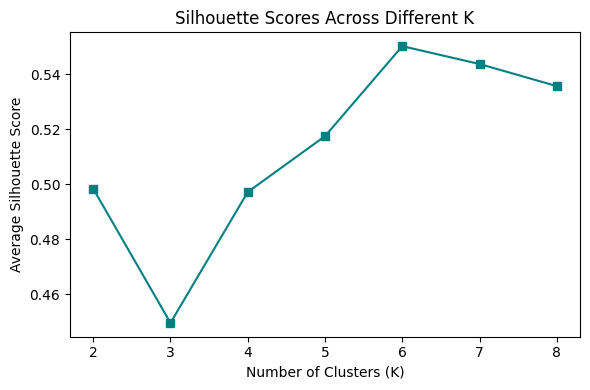


Clustering Metrics Table:
  K = 2 | Inertia: 5591.61 | Silhouette Score: 0.4983
  K = 3 | Inertia: 4098.99 | Silhouette Score: 0.4495
  K = 4 | Inertia: 2838.79 | Silhouette Score: 0.4971
  K = 5 | Inertia: 2102.76 | Silhouette Score: 0.5174
  K = 6 | Inertia: 1697.05 | Silhouette Score: 0.5502
  K = 7 | Inertia: 1436.18 | Silhouette Score: 0.5437
  K = 8 | Inertia: 1179.75 | Silhouette Score: 0.5356


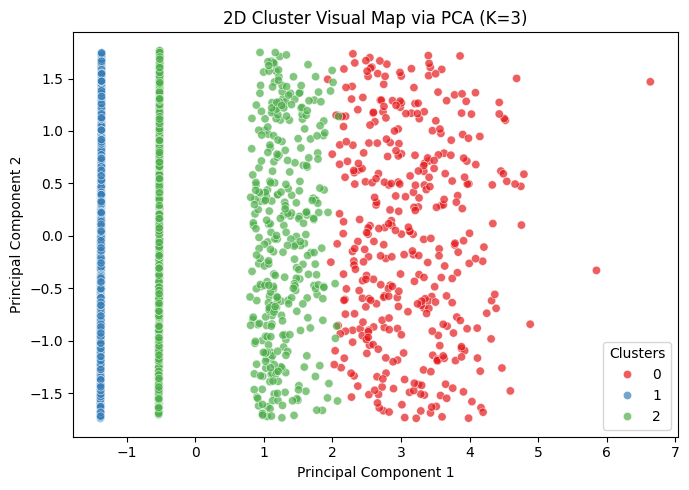


--- Numerical Cluster Profile Centers ---
                Current_Price  Trading_Volume  RSI_14D  Daily_Return  \
Cluster_Labels                                                         
0                  91574.1056    5.208408e+10  50.0919       -0.0008   
1                    334.7390    5.026417e+07  49.6442        0.0011   
2                   1383.9169    1.102578e+10  50.0325        0.0012   

                Cluster_Labels  
Cluster_Labels                  
0                          0.0  
1                          1.0  
2                          2.0  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Load the Dataset
print("--- Loading Cleaned Dataset ---")
df = pd.read_csv('cleaned_data.csv')

# Drop non-numeric IDs or target variables to focus purely on feature structural clustering
X = df.drop(columns=['Daily_Return', 'Instrument_ID'])
X = pd.get_dummies(X, columns=['Asset_Class'], drop_first=True)

# 2. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Elbow Method to find the Optimal Clusters (K from 2 to 8)
inertia_values = []
silhouette_avg_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_avg_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot and save the Elbow Curve
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia_values, marker='o', color='purple', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (In-cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.tight_layout()
plt.savefig('elbow_curve.png')
plt.show()

# Plot and save the Silhouette Scores
plt.figure(figsize=(6, 4))
plt.plot(K_range, silhouette_avg_scores, marker='s', color='teal', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Scores Across Different K')
plt.tight_layout()
plt.savefig('silhouette_scores.png')
plt.show()

# Print metrics out for user reference
print("\nClustering Metrics Table:")
for i, k in enumerate(K_range):
    print(f"  K = {k} | Inertia: {inertia_values[i]:.2f} | Silhouette Score: {silhouette_avg_scores[i]:.4f}")

# 4. Final Optimal Model Training (Using K=3 as default standard market profile split)
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster_Labels'] = final_kmeans.fit_transform(X_scaled).argmin(axis=1) # assigning labels safely

# 5. PCA Dimensionality Reduction for Visualization (2D Projection)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plot and save the Cluster Visualization Map
plt.figure(figsize=(7, 5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Labels', data=df, palette='Set1', alpha=0.7)
plt.title(f'2D Cluster Visual Map via PCA (K={optimal_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Clusters')
plt.tight_layout()
plt.savefig('cluster_visual_map.png')
plt.show()

# 6. Profile Profiling Strategy
print("\n--- Numerical Cluster Profile Centers ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['PCA1', 'PCA2'])
cluster_profile = df.groupby('Cluster_Labels')[numeric_cols].mean()
print(cluster_profile.round(4))